In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(cowplot))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')

var_dim_order <- c('chrom100k', 'chrom5k', 'geneslop2k', 'peaks', 'enhancers')
batch_order <- c('PGP', '50-line')
batch_hexes <- c('#6BAED6', '#FB6A4A')

mean_se_manual <- function(x) {
  data.frame(
    y    = mean(x, na.rm = TRUE),
    ymin = mean(x, na.rm = TRUE) - sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x))),
    ymax = mean(x, na.rm = TRUE) + sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x)))
  )
}

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

umap_theme <- theme(
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### A: mCG UMAPs per feature set

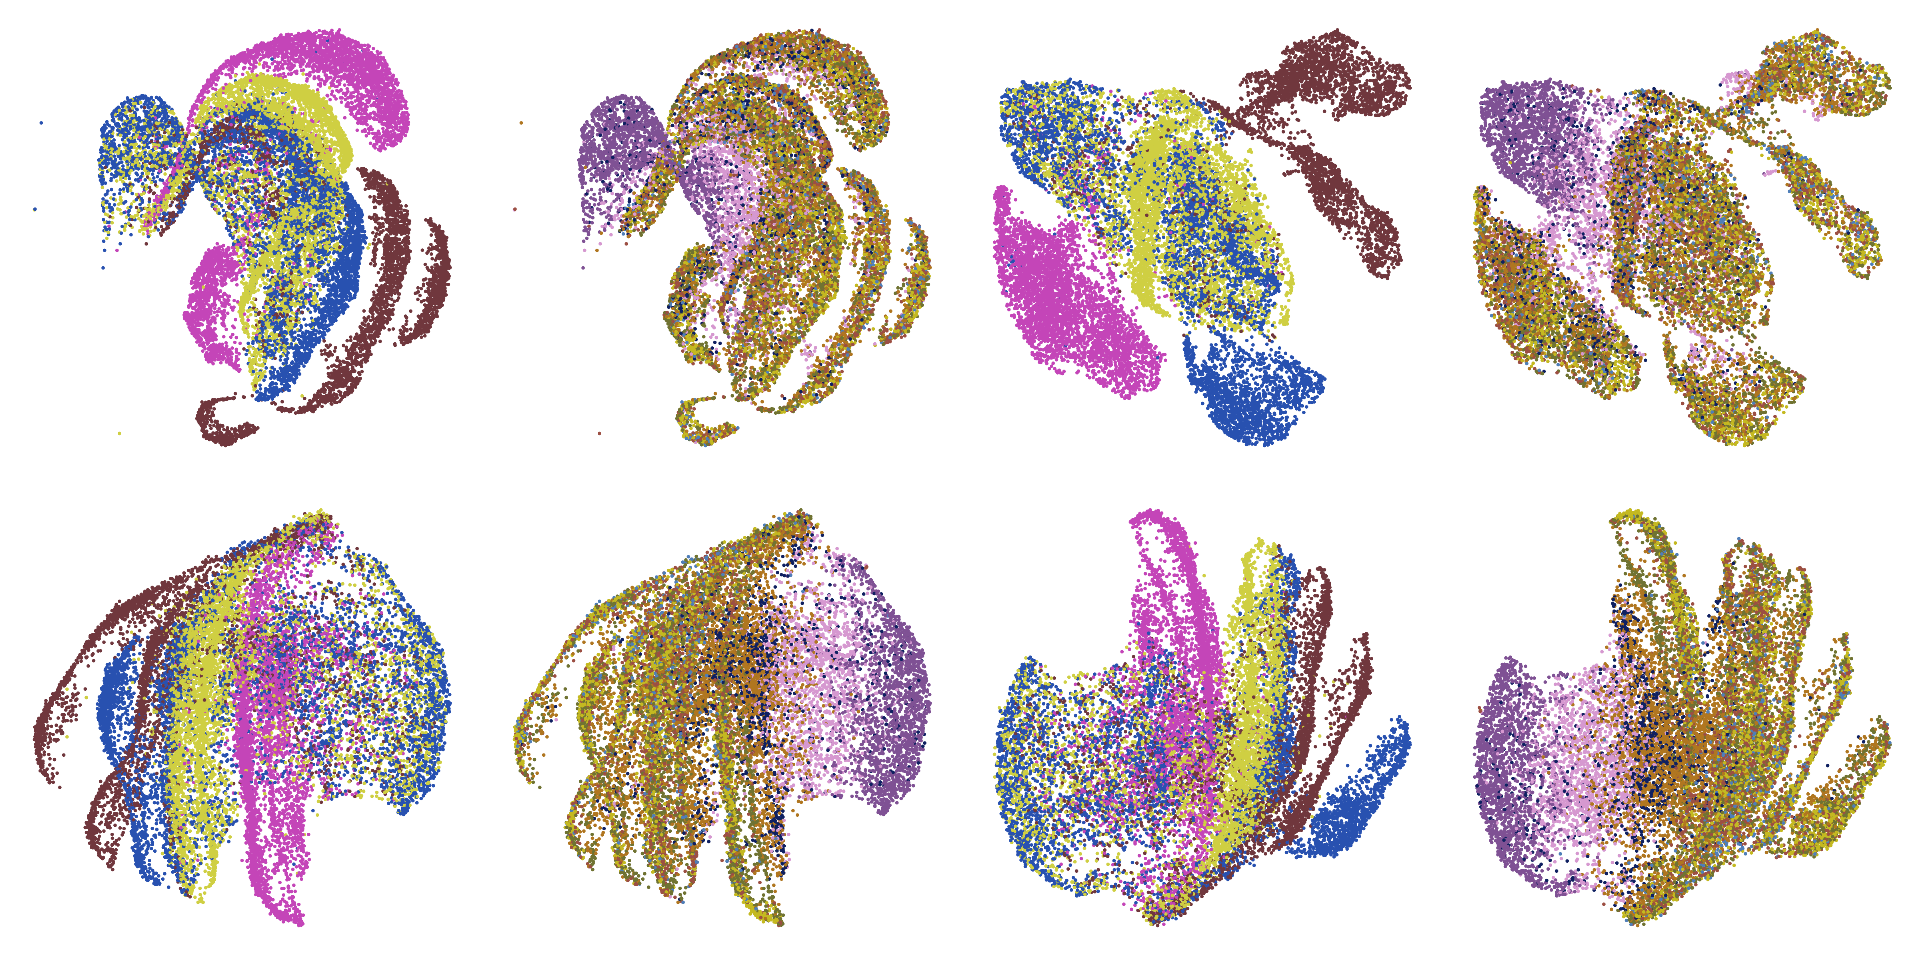

In [ ]:
mcg_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_mcg_feature_umap.csv'
mcg_umap <- as.data.frame(fread(mcg_umap_path))
mcg_umap$cluster <- factor(mcg_umap$cluster, levels=tmp_order)
mask <- !is.na(mcg_umap$cluster)
mcg_umap <- mcg_umap[mask,]
mask <- mcg_umap$var_dim != 'dmrs'
mcg_umap <- mcg_umap[mask,]

var_dims <- unique(mcg_umap$var_dim)
var_dims <- var_dims[-1]
var_dims

donor_list <- list()
clust_list <- list()

for (v in var_dims) {

    tmp_mcg_umap <- mcg_umap %>% filter(var_dim == v)
    set.seed(1)
    shuffled_tmp_mcg_umap <- tmp_mcg_umap[sample(nrow(tmp_mcg_umap)), ]
    p1 <- ggplot(shuffled_tmp_mcg_umap, aes(x = umap0, y = umap1, color = donor)) +
  geom_point_rast(size = 0.1) +
    labs(x = "", y = "", title = v) +
    theme_minimal() +
    umap_theme +
    theme(plot.title = element_blank()) +
        scale_color_manual(values=donor_hexes)

    p2 <- ggplot(shuffled_tmp_mcg_umap, aes(x = umap0, y = umap1, color = cluster)) +
  geom_point_rast(size = 0.1) +
    labs(x = "", y = "", title = v) +
    theme_minimal() +
    umap_theme +
    theme(plot.title = element_blank()) +
        scale_color_manual(values=clust_hexes)

      donor_list[[v]] <- p1
      clust_list[[v]] <- p2
    }

final <- list(donor_list[['chrom5k']], clust_list[['chrom5k']],
              donor_list[['geneslop2k']], clust_list[['geneslop2k']],
              donor_list[['peaks']], clust_list[['peaks']],
              donor_list[['enhancers']], clust_list[['enhancers']])

w = 16
h = 8
options(repr.plot.width=w, repr.plot.height=h)
combined_plot <- plot_grid(plotlist = final, ncol = 4, align = "hv")
combined_plot

### B: nearest neighbors from the same donor, per feature set

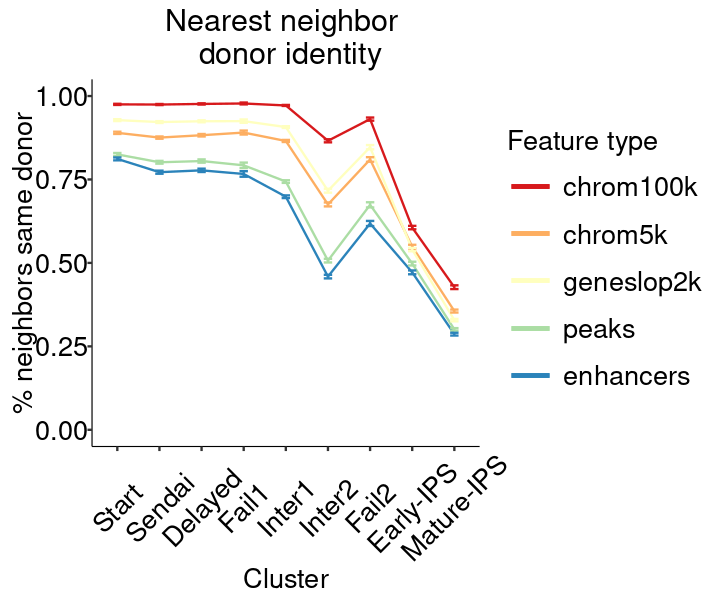

In [ ]:
mature_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2',
                  'Fail2', 'Early-IPS', 'Mature-IPS')

merged_nn_path = paste0(projdir, '/csv/figure2/pgp_mature_features_nn.csv')
merged_nn = as.data.frame(fread(merged_nn_path, sep='\t'))
merged_nn$cluster <- gsub('IPS', 'Early-IPS', merged_nn$cluster)
merged_nn$cluster <- gsub('Mature-Early-IPS', 'Mature-IPS', merged_nn$cluster)
merged_nn$cluster <- factor(merged_nn$cluster, levels=mature_order)
merged_nn$var_dim <- factor(merged_nn$var_dim, levels=var_dim_order)
mask <- !is.na(merged_nn$cluster)
merged_nn <- merged_nn[mask,]

w = 6
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(merged_nn, aes(x = cluster, y = donor_prop, color = var_dim, group = var_dim)) +
  stat_summary(fun.data = mean_se_manual, geom = "line") +
  stat_summary(fun.data = mean_se_manual, geom = "errorbar", width = 0.2) +
  labs(x = "Cluster", y = "% neighbors same donor",
       title = "Nearest neighbor \n donor identity", color = 'Feature type') +
  scale_y_continuous(limits = c(0, 1)) +
  theme_bw() +
  umap_theme +
   theme(axis.text.x = element_text(size=16,angle=45, color='black', vjust=0.5),
        axis.text.y = element_text(size=16,angle=0, color='black'),
        axis.title.x = element_text(size=16),
        axis.title.y = element_text(size=16, angle=90),
         axis.line.x = element_line(linewidth=0.25),
         axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 16),
         legend.title = element_text(size=16),
        plot.title = element_text(size = 18, hjust = 0.5)) +
        scale_color_brewer(palette = 'Spectral') +
          guides(color = guide_legend(override.aes = list(linewidth = 1)),
            shape = guide_legend(title = ''))

### C: CpG mCG distributions, fibroblast and mature-IPS

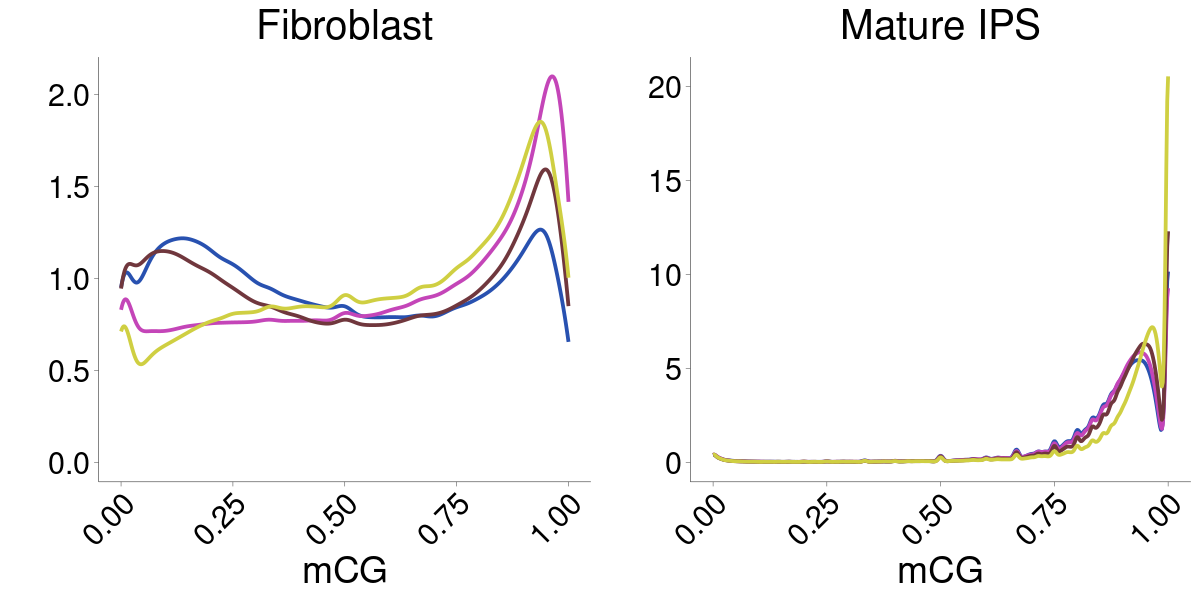

In [ ]:
start_mcg_path = paste0(projdir, '/csv/figure2/start_donor_bins_mcg_dist.csv.gz')
start_mcg = as.data.frame(fread(start_mcg_path, sep='\t'))
start_mcg$donor <- factor(start_mcg$donor, levels=donor_order)

ips_mcg_path = paste0(projdir, '/csv/figure2/ips_donor_bins_mcg_dist.csv.gz')
ips_mcg = as.data.frame(fread(ips_mcg_path, sep='\t'))
ips_mcg$donor <- factor(ips_mcg$donor, levels=donor_order)

make_plot <- function(tmp_df, title_text) {
  ggplot(tmp_df, aes(x = mCG, color = donor)) +
  geom_density(alpha = 1.0, fill = NA, linewidth = 0.8) +
  labs(x = "mCG", y = "", color = "Donor", title=title_text) +
  scale_x_continuous(limits = c(0, 1)) +
  scale_color_manual(values=donor_hexes) +
  theme_bw() +
  base_theme +
  theme(
    axis.text.x = element_text(size = 18, angle = 45, hjust = 1, color='black'),
    axis.text.y = element_text(size = 18, color='black'),
    axis.title.x = element_text(size = 22, color='black'),
    axis.title.y = element_text(size = 22, color='black'),
    axis.line.x = element_line(linewidth=0.1),
    axis.line.y = element_line(linewidth=0.1),
    axis.ticks.x = element_line(linewidth=0.1),
    axis.ticks.y = element_line(linewidth=0.1),
    plot.title = element_text(size=24, hjust=0.5),
    legend.position = "none")
}

titles <- c('Fibroblast', 'Mature IPS')
mcg_dfs <- list(start_mcg, ips_mcg)
plot_list <- list()

for (i in seq_along(mcg_dfs)) {
    tmp_df <- mcg_dfs[[i]]
    title <- titles[i]
    plot_list[[i]] <- make_plot(tmp_df, title)
}

w = 10
h = 5
options(repr.plot.width=w, repr.plot.height=h)
p <- plot_grid(plotlist=plot_list, nrow=1)
p

### G: independent reprogramming experiment UMAPs

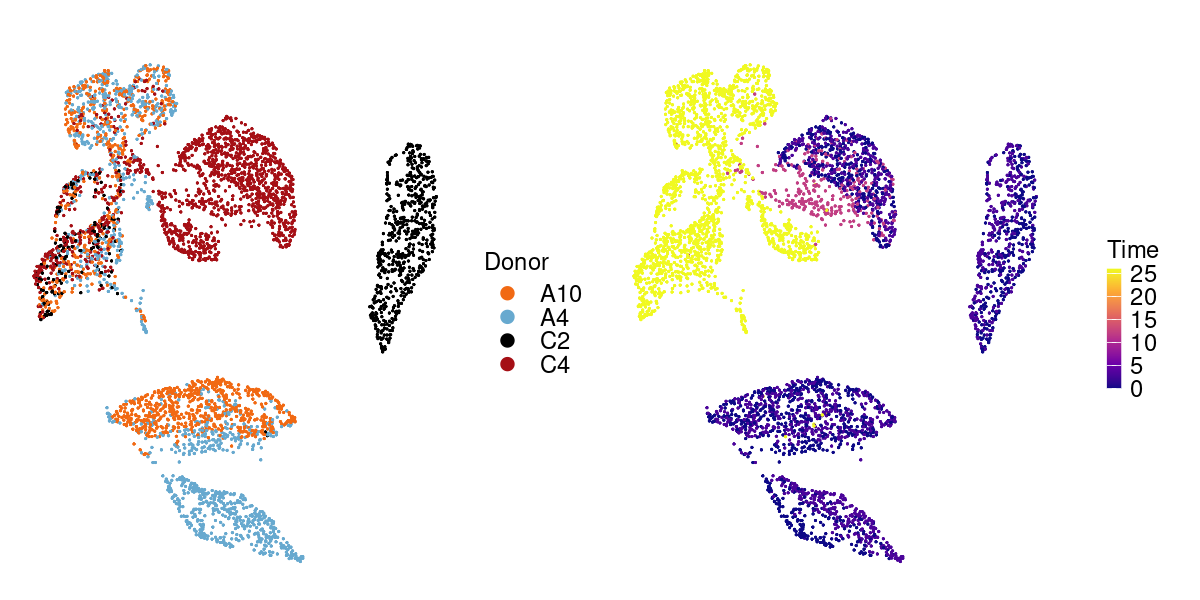

In [ ]:
pilot_donors <- c('A10', 'A4', 'C2', 'C4')
pilot_hexes <- c("#f16913", "#67a9cf", "#000000", "#a50f15")
names(pilot_hexes) <- pilot_donors

pilot_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/snmct_pilot_umap.csv'
pilot_umap <- as.data.frame(fread(pilot_umap_path))
pilot_umap$time_num <- as.numeric(pilot_umap$time_num)

set.seed(1)
shuffled_pilot_umap <- pilot_umap[sample(nrow(pilot_umap)), ]

p1 <- ggplot(shuffled_pilot_umap, aes(x = umap0, y = umap1, color = donor)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", color='Donor', title='') +
  theme_bw() +
  umap_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank(),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
         legend.key.height = unit(0.5, 'cm')) +
        scale_color_manual(values=pilot_hexes) +
          guides(color = guide_legend(override.aes = list(size = 3)),
            shape = guide_legend(title = ''))

p2 <- ggplot(shuffled_pilot_umap, aes(x = umap0, y = umap1, color = time_num)) +
  geom_point_rast(size = 0.1) +
  labs(x = "", y = "", color='Time', title='') +
  theme_bw() +
  umap_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank(),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14),
         legend.key.height = unit(0.5, 'cm')) +
        scale_color_viridis_c(option = "plasma") +
    guides(color = guide_colorbar(barwidth = 0.6,barheight = 5))

w = 10
h = 5
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(p1, p2, align = 'vh')
p

### H: independent experiment nearest neighbors

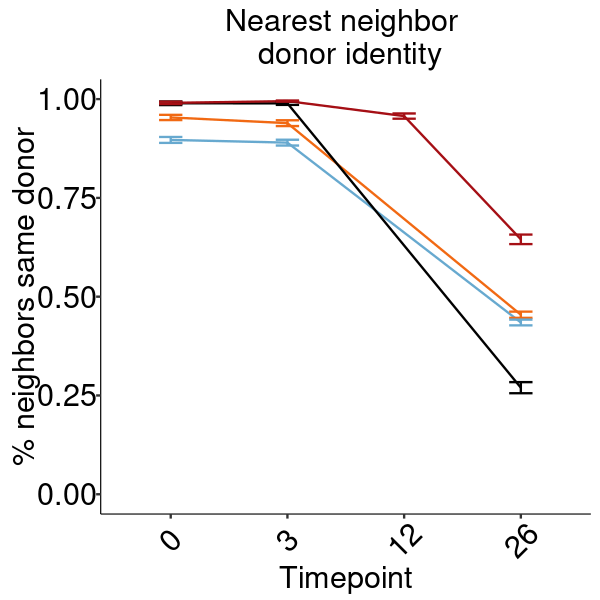

In [ ]:
time_order <- c(0, 3, 12, 26)
pilot_order <- c('A4', 'A10', 'C2', 'C4')
pilot_hexes <- c("#f16913", "#67a9cf", "#000000", "#a50f15")

pilot_nn_path = paste0(projdir, '/csv/figure2/pilot_snmct_mcg_nearest_neighbors.csv')
pilot_nn = as.data.frame(fread(pilot_nn_path, sep='\t'))
pilot_nn$donor <- factor(pilot_nn$donor, levels = pilot_order)
pilot_nn$time_num <- factor(pilot_nn$time_num, levels = time_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(pilot_nn, aes(x = time_num, y = donor_prop, color = donor, group=donor)) +
  stat_summary(fun.data = mean_se_manual, geom = "line") +
  stat_summary(fun.data = mean_se_manual, geom = "errorbar", width = 0.2) +
  labs(x = "Timepoint", y = "% neighbors same donor",
       title = "Nearest neighbor \n donor identity", color = 'Feature type') +
  scale_y_continuous(limits = c(0, 1)) +
  theme_bw() +
  umap_theme +
   theme(axis.text.x = element_text(size=18,angle=45, color='black', vjust=0.5),
        axis.text.y = element_text(size=18,angle=0, color='black'),
        axis.title.x = element_text(size=18),
        axis.title.y = element_text(size=18, angle=90),
         axis.line.x = element_line(linewidth=0.25),
         axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
        plot.title = element_text(size = 18, hjust = 0.5),
         legend.position = 'none') +
        scale_color_manual(values=pilot_hexes)

### I: replicate experiment UMAPs

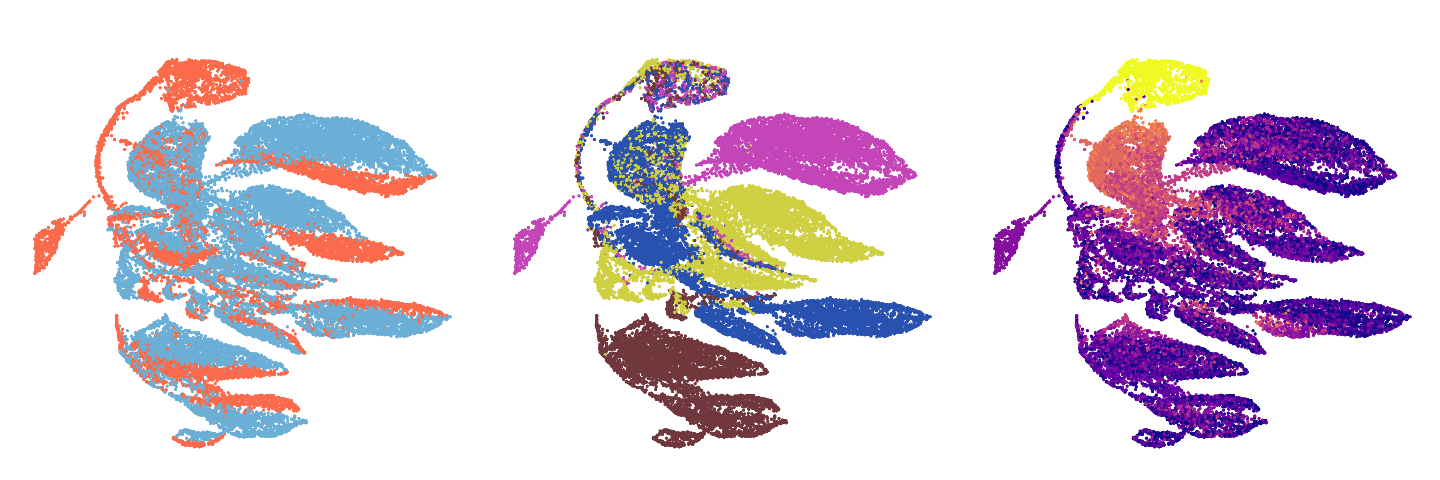

In [ ]:
mcg_umap_path <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures/csv/figure2/pgp_50line_merged_umap.csv'
mcg_umap <- as.data.frame(fread(mcg_umap_path))
mcg_umap$donor <- factor(mcg_umap$donor, levels=donor_order)
mcg_umap$batch <- factor(mcg_umap$batch, levels=batch_order)
mcg_umap$time_num <- as.integer(mcg_umap$time_num)

set.seed(1)
shuffled_mcg_umap <- mcg_umap[sample(nrow(mcg_umap)), ]

p1 <- ggplot(shuffled_mcg_umap, aes(x = umap0, y = umap1, color = batch)) +
  geom_point_rast(size = 0.05) +
labs(x = "", y = "", title = '', color='') +
theme_minimal() +
umap_theme +
   theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
    scale_color_manual(values=batch_hexes)

p2 <- ggplot(shuffled_mcg_umap, aes(x = umap0, y = umap1, color = donor)) +
  geom_point_rast(size = 0.05) +
labs(x = "", y = "", title = '', color='') +
theme_minimal() +
umap_theme +
theme(axis.text.x = element_blank(),
    axis.text.y = element_blank()) +
    scale_color_manual(values=donor_hexes)

p3 <- ggplot(shuffled_mcg_umap, aes(x = umap0, y = umap1, color = time_num)) +
  geom_point_rast(size = 0.05) +
    labs(x = "", y = "", title = '', color='Time') +
    theme_minimal() +
    umap_theme +
    theme(axis.text.x = element_blank(),
        axis.text.y = element_blank()) +
        scale_color_viridis_c(option = "plasma")

w = 12
h = 4
options(repr.plot.width=w, repr.plot.height=h)

p <- plot_grid(p1, p2, p3, nrow=1, align = "h")
p

### J: replicate experiment nearest neighbors

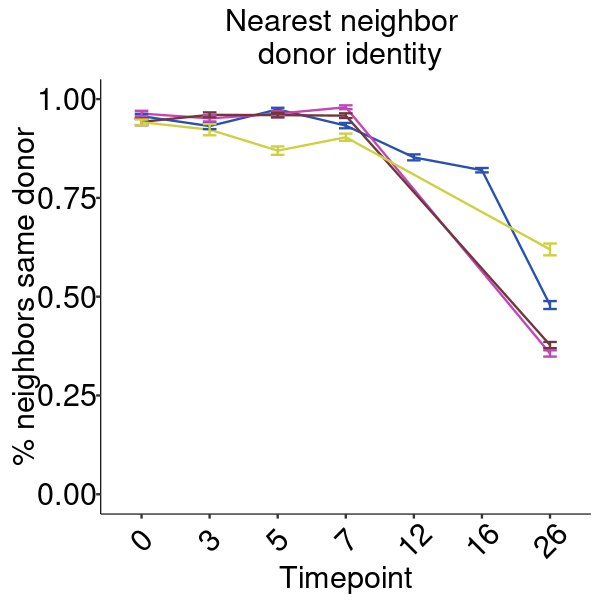

In [ ]:
rep_nn = as.data.frame(fread(paste0(projdir, '/csv/figure2/replicate_snmct_mcg_nearest_neighbors.csv'), sep='\t'))
time_order <- sort(unique(rep_nn$time_num))
rep_nn$donor <- factor(rep_nn$donor, levels = donor_order)
rep_nn$time_num <- factor(rep_nn$time_num, levels = time_order)

w = 5
h = 5
options(repr.plot.width=w, repr.plot.height=h)

ggplot(rep_nn, aes(x = time_num, y = donor_prop, color = donor, group=donor)) +
  stat_summary(fun.data = mean_se_manual, geom = "line") +
  stat_summary(fun.data = mean_se_manual, geom = "errorbar", width = 0.2) +
  labs(x = "Timepoint", y = "% neighbors same donor",
       title = "Nearest neighbor \n donor identity", color = 'Feature type') +
  scale_y_continuous(limits = c(0, 1)) +
  theme_bw() +
  umap_theme +
   theme(axis.text.x = element_text(size=18,angle=45, color='black', vjust=0.5),
        axis.text.y = element_text(size=18,angle=0, color='black'),
        axis.title.x = element_text(size=18),
        axis.title.y = element_text(size=18, angle=90),
         axis.line.x = element_line(linewidth=0.25),
         axis.line.y = element_line(linewidth=0.25),
        axis.ticks.x = element_line(linewidth=0.5),
        axis.ticks.y = element_line(linewidth=0.5),
        plot.title = element_text(size = 18, hjust = 0.5),
         legend.position = 'none') +
        scale_color_manual(values=donor_hexes)

In [ ]:
sessionInfo()

In [ ]:
Sys.time()